# 🎬🔊 Audio-Visual Approximation of Video Semantic Space
## AVMIT Dataset — VGG16 (Visual) + VGGish (Audio) Pre-extracted Embeddings

**Pipeline Overview**

Each `.tfrecord` in the AVMIT tar file is a gzip-compressed `SequenceExample` containing:
- `filename` — video source path (e.g. `writing/zTeYYDA4We4_35.mp4`)
- `label` — action class string (e.g. `typing`)
- `audio` — `(T_a, 128)` float32 VGGish embeddings, one per ~1-sec window
- `visual_object` — `(T_v, 512)` float32 VGG16-fc embeddings, one per keyframe

Because the features are **already extracted**, we skip all raw video/audio decoding and
heavy pre-trained encoders (CLIP, AST, VideoMAE). The pipeline is:

1. **Load** — Parse every `.tfrecord` from the tar, mean-pool temporal steps → flat vectors
2. **Dataset** — `AVMITDataset` serving `(audio_512, visual_512, label_id)`  *(audio projected to 512 to match visual)*
3. **Fusion MLP** — Learns to map `concat[audio; visual]` → a shared 512-d latent
4. **Dim Reduction** — PCA / t-SNE / UMAP to visualise the embedding space
5. **Regression** — MLP regresses fused AV → video GT (mean-pooled visual as proxy GT)
6. **Distillation** — Student AV model mimics the visual-only teacher
7. **Evaluation** — CosSim, MSE, Recall@K, MedR
8. **Dashboard** — Matplotlib + Plotly results

---
**Colab / local:** works on CPU; GPU makes training faster but is not required.


## Section 1 — Install & Imports

In [1]:
# CELL 1.1 — Install dependencies
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

pip_install('tensorflow')           # for parsing tfrecords (CPU-only, no CUDA needed)
pip_install('umap-learn', 'scikit-learn>=1.3')
pip_install('matplotlib', 'plotly', 'seaborn', 'pandas', 'numpy')
pip_install('tqdm')

print('✅  Dependencies ready.')


✅  Dependencies ready.


In [2]:
# CELL 1.2 — Imports
import os, json, copy, time, tarfile, io, warnings, random
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
import umap

from tqdm.auto import tqdm
import tensorflow as tf


warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

print(f'🖥️  Device : {DEVICE}')
print(f'🔢  TF ver : {tf.__version__}')
print(f'🔥  PT ver : {torch.__version__}')


🖥️  Device : cuda
🔢  TF ver : 2.20.0
🔥  PT ver : 2.11.0+cu128


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!cp /content/drive/MyDrive/AVMIT_VGGish_VGG16.tar /content/

In [5]:
!mkdir -p /content/avmit_features
!tar -xf /content/AVMIT_VGGish_VGG16.tar -C /content/avmit_features/

## Section 2 — Configuration

In [6]:
# CELL 2.1 — All hyperparameters in one place
from dataclasses import dataclass, field

@dataclass
class Config:
    # ── Paths ─────────────────────────────────────────────────────────────────
    # Point TAR_PATH to your downloaded AVMIT tar file.
    # All .tfrecord files inside it will be found automatically (recursive).
    TAR_PATH   : str  = '/content/AVMIT_VGGish_VGG16.tar'   # ← change this
    CACHE_DIR  : str  = './avmit_cache'   # parsed embeddings saved here as .npz
    OUTPUT_DIR : str  = './outputs'

    # ── Dataset ───────────────────────────────────────────────────────────────
    MAX_SAMPLES   : int   = -1       # -1 = use all; set e.g. 2000 for quick runs
    VAL_FRACTION  : float = 0.15     # fraction of data held out for validation
    TEST_FRACTION : float = 0.10

    # ── Embedding dims (fixed by the AVMIT pre-extraction) ───────────────────
    AUDIO_DIM  : int = 128           # VGGish output dim
    VISUAL_DIM : int = 512           # VGG16-fc output dim

    # ── Projection / fusion dims ─────────────────────────────────────────────
    PROJ_DIM   : int = 256           # audio projected to this before concat
    LATENT_DIM : int = 512           # shared latent / GT proxy dim

    # ── MLP architecture ─────────────────────────────────────────────────────
    FUSION_HIDDEN   : List[int] = field(default_factory=lambda: [512, 512])
    STUDENT_HIDDEN  : List[int] = field(default_factory=lambda: [512, 256])
    DROPOUT         : float = 0.2

    # ── Training ─────────────────────────────────────────────────────────────
    BATCH_SIZE      : int   = 128
    REG_EPOCHS      : int   = 60
    DIST_EPOCHS     : int   = 60
    LR              : float = 3e-4
    WEIGHT_DECAY    : float = 1e-4
    USE_AMP         : bool  = True

    # ── Dim-reduction ─────────────────────────────────────────────────────────
    PCA_COMPONENTS  : int   = 50
    TSNE_PERPLEXITY : int   = 30
    UMAP_NEIGHBORS  : int   = 15
    UMAP_METRIC     : str   = 'cosine'

CFG = Config()
Path(CFG.CACHE_DIR).mkdir(parents=True, exist_ok=True)
Path(CFG.OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print('✅  Config loaded.')
print(f'   TAR_PATH   : {'/content/AVMIT_VGGish_VGG16.tar'}')
print(f'   AUDIO_DIM  : {CFG.AUDIO_DIM}  (VGGish)')
print(f'   VISUAL_DIM : {CFG.VISUAL_DIM}  (VGG16-fc)')


✅  Config loaded.
   TAR_PATH   : /content/AVMIT_VGGish_VGG16.tar
   AUDIO_DIM  : 128  (VGGish)
   VISUAL_DIM : 512  (VGG16-fc)


## Section 3 — AVMIT TFRecord Parser

Each `.tfrecord` is a **gzip-compressed `SequenceExample`** with:

| Field | Type | Shape | Description |
|---|---|---|---|
| `filename` | context bytes | scalar | e.g. `writing/zTeYYDA4We4_35.mp4` |
| `label` | context bytes | scalar | action class string |
| `audio_timesteps` | context int64 | scalar | number of audio windows |
| `visual_timesteps` | context int64 | scalar | number of visual keyframes |
| `audio` | sequence bytes | `(T_a, 128)` | VGGish float32 embeddings |
| `visual_object` | sequence bytes | `(T_v, 512)` | VGG16-fc float32 embeddings |


In [7]:
# CELL 3.1 — Pure-Python TFRecord + SequenceExample parser (no TensorFlow)

import gzip, struct
import numpy as np

def _parse_varint(buf, pos):
    result, shift = 0, 0
    while pos < len(buf):
        b = buf[pos]; pos += 1
        result |= (b & 0x7F) << shift
        if not (b & 0x80): break
        shift += 7
    return result, pos

def _parse_proto_fields(buf, start, end):
    fields = {}; pos = start
    while pos < end:
        if pos >= len(buf): break
        tag, pos = _parse_varint(buf, pos)
        if tag == 0: break
        fn = tag >> 3; wt = tag & 0x7
        try:
            if wt == 0:
                v, pos = _parse_varint(buf, pos)
                fields.setdefault(fn, []).append(('varint', v))
            elif wt == 2:
                l, pos = _parse_varint(buf, pos)
                fields.setdefault(fn, []).append(('bytes', buf[pos:pos+l])); pos += l
            elif wt == 1:
                fields.setdefault(fn, []).append(('64bit', buf[pos:pos+8])); pos += 8
            elif wt == 5:
                fields.setdefault(fn, []).append(('32bit', buf[pos:pos+4])); pos += 4
            else:
                break
        except Exception:
            break
    return fields

def parse_sequence_example(buf: bytes):
    """
    Parse one AVMIT SequenceExample from raw bytes.

    Accepts BOTH:
      • raw tfrecord bytes  (what tarfile.extractfile() returns for .tar.gz archives)
      • gzip-wrapped bytes  (individually gzip-compressed .tfrecord files on disk)

    Returns dict {label, filename, audio (T,128), visual (T,512)} or None on failure.
    """
    # Auto-detect and handle gzip wrapping
    try:
        buf = gzip.decompress(buf)
    except Exception:
        pass  # Already raw tfrecord bytes — no action needed

    try:
        rec_len = struct.unpack_from('<Q', buf, 0)[0]
        if rec_len == 0 or rec_len > len(buf):
            return None
        proto = buf[12:12 + rec_len]
        top   = _parse_proto_fields(proto, 0, len(proto))
    except Exception:
        return None

    label = ''; filename = ''
    audio_steps = []; visual_steps = []

    # ── Context features ──────────────────────────────────────────────────────
    for _, ctx_bytes in top.get(1, []):
        ctx = _parse_proto_fields(ctx_bytes, 0, len(ctx_bytes))
        for _, entry_bytes in ctx.get(1, []):
            entry = _parse_proto_fields(entry_bytes, 0, len(entry_bytes))
            if 1 not in entry or 2 not in entry:
                continue
            key  = entry[1][0][1].decode('utf-8', errors='replace')
            feat = _parse_proto_fields(entry[2][0][1], 0, len(entry[2][0][1]))
            if key == 'label' and 1 in feat:
                bl    = _parse_proto_fields(feat[1][0][1], 0, len(feat[1][0][1]))
                label = bl[1][0][1].decode('utf-8') if 1 in bl else ''
            elif key == 'filename' and 1 in feat:
                bl       = _parse_proto_fields(feat[1][0][1], 0, len(feat[1][0][1]))
                filename = bl[1][0][1].decode('utf-8') if 1 in bl else ''

    # ── Sequence feature lists ────────────────────────────────────────────────
    for _, fl_bytes in top.get(2, []):
        fl = _parse_proto_fields(fl_bytes, 0, len(fl_bytes))
        for _, entry_bytes in fl.get(1, []):
            entry = _parse_proto_fields(entry_bytes, 0, len(entry_bytes))
            if 1 not in entry or 2 not in entry:
                continue
            key   = entry[1][0][1].decode('utf-8', errors='replace')
            flist = _parse_proto_fields(entry[2][0][1], 0, len(entry[2][0][1]))
            steps = []
            for _, feat_bytes in flist.get(1, []):
                feat = _parse_proto_fields(feat_bytes, 0, len(feat_bytes))
                if 1 in feat:
                    bl = _parse_proto_fields(feat[1][0][1], 0, len(feat[1][0][1]))
                    if 1 in bl:
                        steps.append(np.frombuffer(bl[1][0][1], dtype=np.float32).copy())
            if key == 'audio':
                audio_steps = steps
            elif key == 'visual_object':
                visual_steps = steps

    if not audio_steps or not visual_steps:
        return None

    return {
        'label'   : label,
        'filename': filename,
        'audio'   : np.stack(audio_steps),   # (T_a, 128)
        'visual'  : np.stack(visual_steps),  # (T_v, 512)
    }


# ── Smoke-test on uploaded sample ────────────────────────────────────────────
import os
for p in ['/content/1780297998227_zTeYYDA4We4_35.tfrecord',
          '/mnt/user-data/uploads/1780297998227_zTeYYDA4We4_35.tfrecord']:
    if os.path.exists(p):
        rec = parse_sequence_example(open(p, 'rb').read())
        if rec:
            print(f'✅  Parser OK — label={rec["label"]}  audio={rec["audio"].shape}  visual={rec["visual"].shape}')
        else:
            print('⚠️  Parser returned None — check the file path')
        break

In [8]:
# CELL 3.2 — Load entire AVMIT tar → flat numpy arrays (with caching)

def load_avmit_tar(tar_path: str, cfg) -> dict:
    """
    Walk every .tfrecord inside the AVMIT tar, parse each one, mean-pool
    temporal steps → one flat vector per sample, return numpy arrays.

    Works with:
      • .tar      — files inside are raw (non-gzip) tfrecords
      • .tar.gz / .tgz — tarfile decompresses transparently; files still raw inside
      • .tar where files are individually gzip-compressed tfrecords

    Results are cached as .npz so subsequent runs are instant.
    """
    cache_file = Path(cfg.CACHE_DIR) / 'avmit_embeddings.npz'
    if cache_file.exists():
        print(f'📂  Loading cached embeddings from {cache_file}')
        data = dict(np.load(cache_file, allow_pickle=True))
        data['labels']    = data['labels'].astype(str)
        data['filenames'] = data['filenames'].astype(str)
        print(f'   Loaded {len(data["label_ids"])} samples  |  {len(data["class_names"])} classes')
        return data

    print(f'📦  Parsing {tar_path} ...')
    audio_list, visual_list, label_list, fname_list = [], [], [], []
    n_failed = 0

    with tarfile.open(tar_path, 'r:*') as tar:
        members = [m for m in tar.getmembers()
                   if m.name.endswith('.tfrecord') and m.isfile()]
        print(f'   Found {len(members)} tfrecord files.')

        if cfg.MAX_SAMPLES > 0:
            members = members[:cfg.MAX_SAMPLES]

        for member in tqdm(members, desc='Parsing tfrecords'):
            f = tar.extractfile(member)
            if f is None:
                n_failed += 1
                continue

            # ── KEY FIX ──────────────────────────────────────────────────────
            # Pass raw bytes DIRECTLY to parse_sequence_example.
            # Do NOT pre-decompress here — the parser handles both gzip and raw.
            # Pre-decompressing caused 57147/57148 failures because files inside
            # a .tar.gz are already raw tfrecord bytes after tarfile extraction.
            raw_bytes = f.read()
            rec = parse_sequence_example(raw_bytes)

            if rec is None:
                n_failed += 1
                continue

            audio_list.append(rec['audio'].mean(axis=0).astype(np.float32))    # (128,)
            visual_list.append(rec['visual'].mean(axis=0).astype(np.float32))  # (512,)
            label_list.append(rec['label'])
            fname_list.append(rec['filename'])

    print(f'   Parsed  : {len(audio_list)} samples')
    print(f'   Failed  : {n_failed} files')

    if len(audio_list) == 0:
        raise RuntimeError(
            "No samples parsed. The tfrecords may have an unexpected structure.\n"
            "Try running Cell 3.1 smoke-test on a single extracted .tfrecord to debug."
        )

    from sklearn.preprocessing import LabelEncoder
    le       = LabelEncoder()
    label_ids = le.fit_transform(label_list).astype(np.int64)
    print(f'   Classes : {len(le.classes_)}')

    data = {
        'audio_embs'  : np.stack(audio_list),
        'visual_embs' : np.stack(visual_list),
        'labels'      : np.array(label_list),
        'label_ids'   : label_ids,
        'filenames'   : np.array(fname_list),
        'class_names' : le.classes_,
    }
    np.savez_compressed(cache_file, **data)
    print(f'✅  Saved cache → {cache_file}')
    return data


# ── Delete stale cache before re-loading ─────────────────────────────────────
import shutil
stale = Path(CFG.CACHE_DIR) / 'avmit_embeddings.npz'
if stale.exists():
    stale.unlink()
    print('🗑️  Deleted stale cache (will re-parse with fixed parser)')

data = load_avmit_tar(CFG.TAR_PATH, CFG)
N_CLASSES = len(data['class_names'])
CFG.__dict__['N_CLASSES'] = N_CLASSES

print(f'\n   audio_embs  : {data["audio_embs"].shape}')
print(f'   visual_embs : {data["visual_embs"].shape}')
print(f'   Classes     : {N_CLASSES}')
print(f'   Sample labels: {list(data["class_names"][:10])} ...')

📦  Parsing /content/AVMIT_VGGish_VGG16.tar ...
   Found 57148 tfrecord files.


Parsing tfrecords:   0%|          | 0/57148 [00:00<?, ?it/s]

   Parsed  : 57148 samples
   Failed  : 0 files
   Classes : 41
✅  Saved cache → avmit_cache/avmit_embeddings.npz

   audio_embs  : (57148, 128)
   visual_embs : (57148, 512)
   Classes     : 41
   Sample labels: [np.str_('barking'), np.str_('bowling'), np.str_('boxing'), np.str_('bubbling'), np.str_('calling'), np.str_('chopping'), np.str_('clipping'), np.str_('coughing'), np.str_('crashing'), np.str_('diving')] ...


In [9]:
# CELL 3.3 — Train / Val / Test split

from sklearn.model_selection import train_test_split

N = len(data['label_ids'])
idx = np.arange(N)

# Stratified split so each class appears in all splits
idx_trainval, idx_test = train_test_split(
    idx, test_size=CFG.TEST_FRACTION,
    stratify=data['label_ids'], random_state=SEED)

idx_train, idx_val = train_test_split(
    idx_trainval,
    test_size=CFG.VAL_FRACTION / (1 - CFG.TEST_FRACTION),
    stratify=data['label_ids'][idx_trainval], random_state=SEED)

def split_data(idx):
    return {
        'audio_embs' : data['audio_embs'][idx],
        'visual_embs': data['visual_embs'][idx],
        'labels'     : data['labels'][idx],
        'label_ids'  : data['label_ids'][idx],
    }

train_data = split_data(idx_train)
val_data   = split_data(idx_val)
test_data  = split_data(idx_test)

print(f'✅  Split complete:')
print(f'   Train : {len(idx_train):>5}  samples')
print(f'   Val   : {len(idx_val):>5}  samples')
print(f'   Test  : {len(idx_test):>5}  samples')


✅  Split complete:
   Train : 42860  samples
   Val   :  8573  samples
   Test  :  5715  samples


## Section 4 — PyTorch Dataset & DataLoaders

In [10]:
# CELL 4.1 — AVMITDataset

class AVMITDataset(Dataset):
    """
    Lightweight PyTorch Dataset wrapping pre-extracted AVMIT embeddings.

    Each item returns:
        audio_emb  : Tensor (AUDIO_DIM,)   = 128-d VGGish mean-pooled
        visual_emb : Tensor (VISUAL_DIM,)  = 512-d VGG16-fc mean-pooled
        av_concat  : Tensor (AUDIO_DIM + VISUAL_DIM,)  = concat input to MLP
        label_id   : int
    """
    def __init__(self, split_dict: Dict[str, np.ndarray]):
        self.audio  = torch.from_numpy(split_dict['audio_embs']).float()
        self.visual = torch.from_numpy(split_dict['visual_embs']).float()
        self.labels = torch.from_numpy(split_dict['label_ids']).long()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        a = self.audio[i]
        v = self.visual[i]
        return {
            'audio_emb' : a,
            'visual_emb': v,
            'av_concat' : torch.cat([a, v], dim=-1),   # (640,)
            'label_id'  : self.labels[i],
        }


def make_loaders(cfg: Config):
    train_ds = AVMITDataset(train_data)
    val_ds   = AVMITDataset(val_data)
    test_ds  = AVMITDataset(test_data)
    kw = dict(num_workers=0, pin_memory=(DEVICE.type=='cuda'))
    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,  **kw)
    val_loader   = DataLoader(val_ds,   batch_size=cfg.BATCH_SIZE, shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  batch_size=cfg.BATCH_SIZE, shuffle=False, **kw)
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(CFG)

AV_DIM = CFG.AUDIO_DIM + CFG.VISUAL_DIM    # 640 — input to all MLPs
GT_DIM = CFG.VISUAL_DIM                    # 512 — visual embedding as GT proxy

print(f'✅  DataLoaders ready.')
print(f'   AV input dim  : {AV_DIM}  (audio {CFG.AUDIO_DIM} + visual {CFG.VISUAL_DIM})')
print(f'   GT proxy dim  : {GT_DIM}  (visual mean-pool)')
print(f'   Batches/epoch : train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}')


✅  DataLoaders ready.
   AV input dim  : 640  (audio 128 + visual 512)
   GT proxy dim  : 512  (visual mean-pool)
   Batches/epoch : train=335, val=67, test=45


## Section 5 — Dimensionality Reduction (PCA / t-SNE / UMAP)

In [11]:
# CELL 5.1 — Run PCA, t-SNE, UMAP on the AV embedding space

def run_dim_reduction(split_dict: Dict, cfg: Config, split_name='train') -> Dict:
    audio  = split_dict['audio_embs']    # (N, 128)
    visual = split_dict['visual_embs']   # (N, 512)
    av     = np.concatenate([audio, visual], axis=1)   # (N, 640)

    scaler    = StandardScaler()
    av_scaled = scaler.fit_transform(av)

    results = {}

    # PCA
    print(f'  PCA (n={cfg.PCA_COMPONENTS})...')
    pca = PCA(n_components=min(cfg.PCA_COMPONENTS, av_scaled.shape[1]), random_state=SEED)
    av_pca = pca.fit_transform(av_scaled)
    results['pca_2d']        = av_pca[:, :2]
    results['pca_full']      = av_pca
    results['pca_variance']  = pca.explained_variance_ratio_
    print(f'     Cumulative variance: {pca.explained_variance_ratio_.cumsum()[-1]:.3f}')

    # t-SNE (on PCA-reduced for speed)
    n_tsne_input = min(50, av_pca.shape[1])
    print(f'  t-SNE (perplexity={cfg.TSNE_PERPLEXITY})...')
    tsne = TSNE(n_components=2, perplexity=cfg.TSNE_PERPLEXITY,
                n_iter=1000, random_state=SEED, learning_rate='auto', init='pca')
    results['tsne_2d'] = tsne.fit_transform(av_pca[:, :n_tsne_input])

    # UMAP 2D + 3D
    print(f'  UMAP 2D...')
    results['umap_2d'] = umap.UMAP(
        n_components=2, n_neighbors=cfg.UMAP_NEIGHBORS,
        min_dist=0.1, metric=cfg.UMAP_METRIC, random_state=SEED
    ).fit_transform(av_scaled)

    print(f'  UMAP 3D...')
    results['umap_3d'] = umap.UMAP(
        n_components=3, n_neighbors=cfg.UMAP_NEIGHBORS,
        min_dist=0.1, metric=cfg.UMAP_METRIC, random_state=SEED
    ).fit_transform(av_scaled)

    print(f'✅  Dim reduction done for {split_name}.')
    return results

print('📊  Running dimensionality reduction on training set...')
dim_results = run_dim_reduction(train_data, CFG, split_name='train')


📊  Running dimensionality reduction on training set...
  PCA (n=50)...
     Cumulative variance: 0.569
  t-SNE (perplexity=30)...
  UMAP 2D...
  UMAP 3D...
✅  Dim reduction done for train.


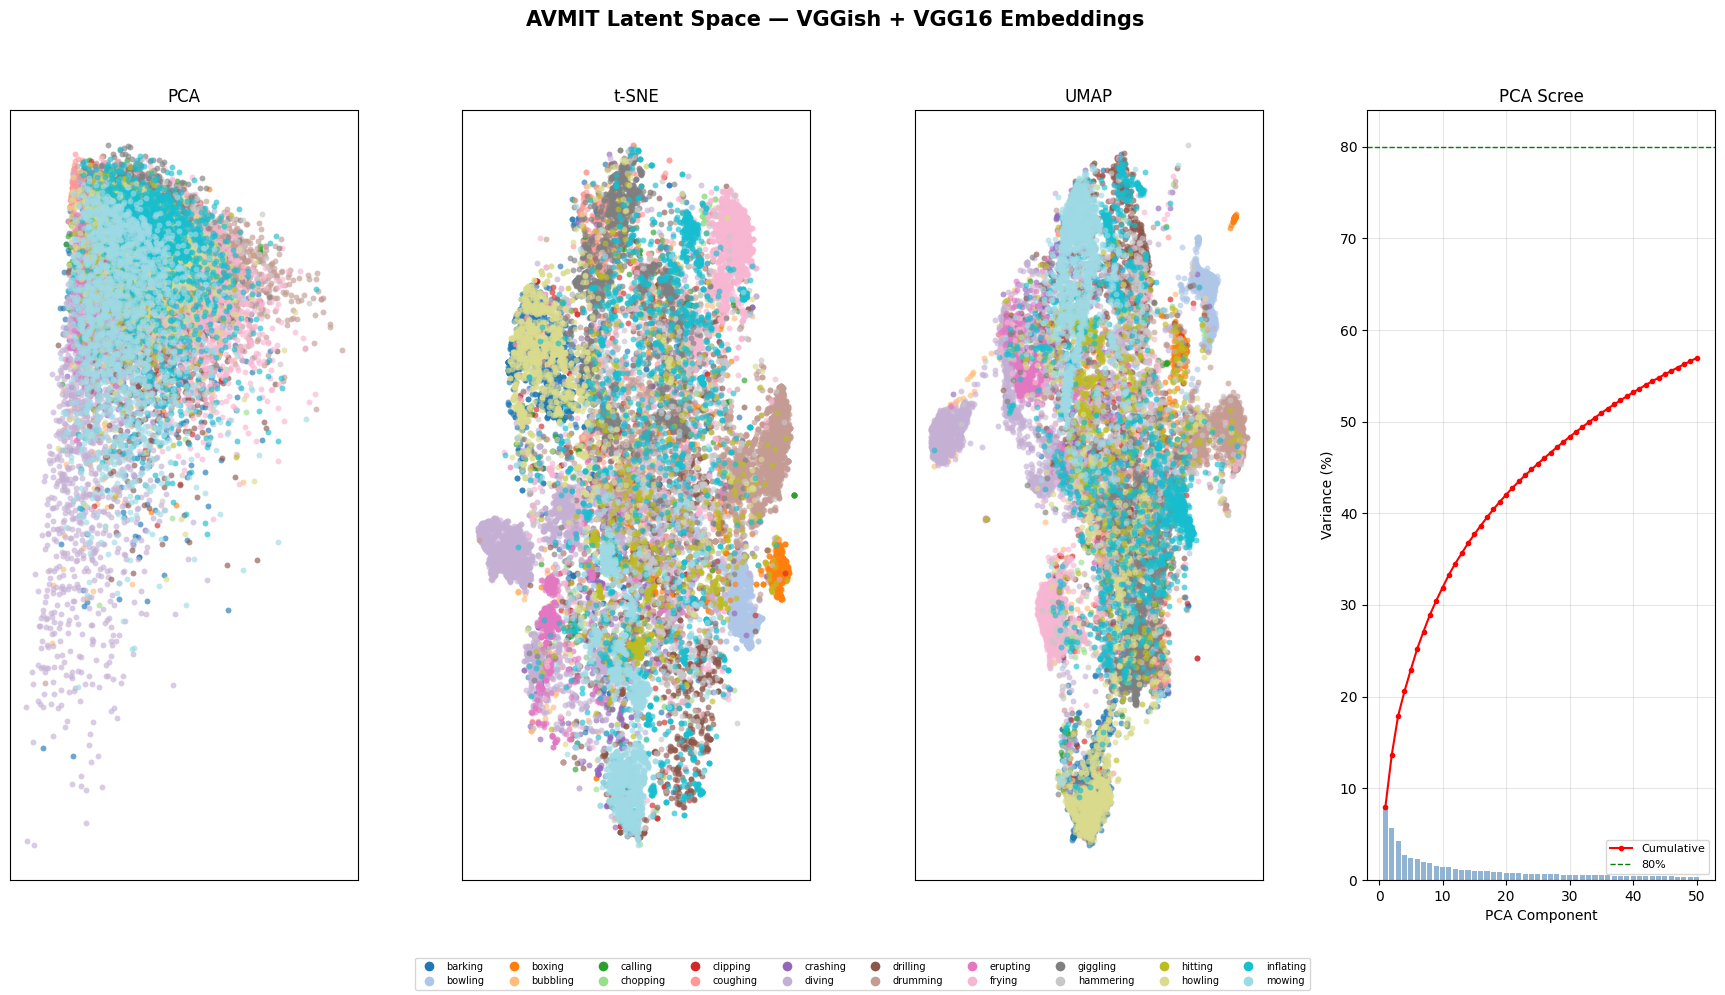

💾  Saved to outputs/embedding_vis.png


In [12]:
# CELL 5.2 — Visualise PCA / t-SNE / UMAP (Matplotlib)

def plot_embedding_grid(dim_results, labels, label_ids, class_names, save_dir):
    unique_ids = np.unique(label_ids)
    n_shown    = min(len(unique_ids), 20)
    cmap       = plt.cm.get_cmap('tab20', n_shown)

    fig = plt.figure(figsize=(22, 10))
    fig.suptitle('AVMIT Latent Space — VGGish + VGG16 Embeddings',
                 fontsize=15, fontweight='bold')
    gs = gridspec.GridSpec(1, 4, figure=fig, wspace=0.3)

    configs = [
        ('PCA',   dim_results['pca_2d']),
        ('t-SNE', dim_results['tsne_2d']),
        ('UMAP',  dim_results['umap_2d']),
    ]
    for col, (name, data2d) in enumerate(configs):
        ax = fig.add_subplot(gs[0, col])
        for i, uid in enumerate(unique_ids[:n_shown]):
            mask = label_ids == uid
            ax.scatter(data2d[mask, 0], data2d[mask, 1],
                       c=[cmap(i)], label=class_names[uid] if uid < len(class_names) else str(uid),
                       alpha=0.65, s=18, linewidths=0)
        ax.set_title(name, fontsize=12)
        ax.set_xticks([]); ax.set_yticks([])

    # PCA scree
    ax_var = fig.add_subplot(gs[0, 3])
    var    = dim_results['pca_variance']
    cumvar = np.cumsum(var)
    ax_var.bar(range(1, len(var)+1), var*100, alpha=0.6, color='steelblue')
    ax_var.plot(range(1, len(cumvar)+1), cumvar*100, 'r-o', ms=3, label='Cumulative')
    ax_var.axhline(80, color='green', ls='--', lw=1, label='80%')
    ax_var.set_xlabel('PCA Component'); ax_var.set_ylabel('Variance (%)')
    ax_var.set_title('PCA Scree'); ax_var.legend(fontsize=8); ax_var.grid(alpha=0.3)

    # Legend
    lbl_names = [class_names[uid] if uid < len(class_names) else str(uid) for uid in unique_ids[:n_shown]]
    fig.legend([plt.Line2D([0],[0],marker='o',color='w',markerfacecolor=cmap(i),ms=8)
                for i in range(n_shown)],
               lbl_names, loc='lower center', ncol=min(10, n_shown),
               fontsize=7, framealpha=0.8)

    path = Path(save_dir) / 'embedding_vis.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'💾  Saved to {path}')

plot_embedding_grid(dim_results, train_data['labels'], train_data['label_ids'],
                    data['class_names'], CFG.OUTPUT_DIR)


In [13]:
# CELL 5.3 — Interactive 3D UMAP (Plotly)

def plot_umap_3d(umap_3d, labels, label_ids, title, save_path):
    df = pd.DataFrame({
        'UMAP-1': umap_3d[:,0], 'UMAP-2': umap_3d[:,1], 'UMAP-3': umap_3d[:,2],
        'label': labels,
    })
    fig = px.scatter_3d(df, x='UMAP-1', y='UMAP-2', z='UMAP-3',
                        color='label', opacity=0.7, title=title,
                        width=950, height=700,
                        color_discrete_sequence=px.colors.qualitative.Alphabet)
    fig.update_traces(marker=dict(size=3))
    fig.update_layout(legend_title_text='Class', font_size=11)
    fig.write_html(save_path)
    fig.show()
    print(f'💾  Saved to {save_path}')

plot_umap_3d(dim_results['umap_3d'], train_data['labels'], train_data['label_ids'],
             'UMAP 3D — AVMIT AV Embeddings',
             f'{CFG.OUTPUT_DIR}/umap_3d.html')


💾  Saved to ./outputs/umap_3d.html


## Section 6 — Fusion MLP & Latent Space Regression

In [14]:
# CELL 6.1 — FusionMLP: concat[audio; visual] → latent

class FusionMLP(nn.Module):
    """
    Maps concat[audio_emb; visual_emb] → 512-d fused latent.
    Used as regression model to predict the GT (visual) embedding.
    Input  : (B, 640)   = audio(128) + visual(512)
    Output : (B, 512)   normalised
    """
    def __init__(self, input_dim: int, output_dim: int,
                 hidden_dims: List[int], dropout: float = 0.2):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.LayerNorm(h), nn.GELU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


reg_model = FusionMLP(AV_DIM, GT_DIM, CFG.FUSION_HIDDEN, CFG.DROPOUT).to(DEVICE)
n_params  = sum(p.numel() for p in reg_model.parameters() if p.requires_grad)
print(f'✅  FusionMLP  — params: {n_params:,}')
print(f'   {AV_DIM}  →  {CFG.FUSION_HIDDEN}  →  {GT_DIM}')


✅  FusionMLP  — params: 855,552
   640  →  [512, 512]  →  512


In [15]:
# CELL 6.2 — Regression training loop (MSE + CosSim loss)

class RegLoss(nn.Module):
    def __init__(self, w_mse=0.5, w_cos=0.5):
        super().__init__()
        self.w_mse = w_mse; self.w_cos = w_cos
        self.mse   = nn.MSELoss()
    def forward(self, pred, target):
        mse = self.mse(pred, target)
        cos = 1.0 - F.cosine_similarity(pred, target, dim=-1).mean()
        return self.w_mse*mse + self.w_cos*cos, {'mse': mse.item(), 'cos': cos.item()}


def train_regression(model, train_loader, val_loader, cfg: Config):
    criterion = RegLoss()
    opt       = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    sched     = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.REG_EPOCHS, eta_min=1e-6)
    scaler    = GradScaler('cuda', enabled=cfg.USE_AMP and DEVICE.type=='cuda')
    history   = {'train_loss':[], 'val_loss':[], 'train_cos':[], 'val_cos':[], 'train_mse':[], 'val_mse':[]}
    best_val, best_state = float('inf'), None

    for epoch in range(1, cfg.REG_EPOCHS + 1):
        model.train()
        tr_loss, tr_mse, tr_cos, n = 0,0,0,0
        for batch in train_loader:
            av     = batch['av_concat'].to(DEVICE)
            target = batch['visual_emb'].to(DEVICE)   # GT = visual embedding
            opt.zero_grad()
            with autocast('cuda', enabled=cfg.USE_AMP and DEVICE.type=='cuda'):
                pred = model(av)
                loss, sub = criterion(pred, target)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
            B = av.size(0)
            tr_loss+=loss.item()*B; tr_mse+=sub['mse']*B; tr_cos+=sub['cos']*B; n+=B

        model.eval()
        vl_loss, vl_mse, vl_cos, nv = 0,0,0,0
        with torch.no_grad():
            for batch in val_loader:
                av     = batch['av_concat'].to(DEVICE)
                target = batch['visual_emb'].to(DEVICE)
                with autocast('cuda', enabled=cfg.USE_AMP and DEVICE.type=='cuda'):
                    pred = model(av); loss, sub = criterion(pred, target)
                B = av.size(0)
                vl_loss+=loss.item()*B; vl_mse+=sub['mse']*B; vl_cos+=sub['cos']*B; nv+=B

        history['train_loss'].append(tr_loss/n); history['val_loss'].append(vl_loss/nv)
        history['train_mse'].append(tr_mse/n);  history['val_mse'].append(vl_mse/nv)
        history['train_cos'].append(1-tr_cos/n);history['val_cos'].append(1-vl_cos/nv)
        sched.step()

        if vl_loss/nv < best_val:
            best_val = vl_loss/nv
            best_state = copy.deepcopy(model.state_dict())

        if epoch % 10 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{cfg.REG_EPOCHS} | '
                  f'train loss {history["train_loss"][-1]:.4f}  '
                  f'val loss {history["val_loss"][-1]:.4f}  '
                  f'val CosSim {history["val_cos"][-1]:.4f}')

    model.load_state_dict(best_state)
    torch.save(model.state_dict(), Path(cfg.OUTPUT_DIR)/'reg_model.pt')
    print(f'\n✅  Regression done. Best val loss: {best_val:.4f}')
    return history


print('🚂  Training Fusion MLP (regression)...')
reg_history = train_regression(reg_model, train_loader, val_loader, CFG)


🚂  Training Fusion MLP (regression)...
  Epoch   1/60 | train loss 7.1858  val loss 7.0300  val CosSim 0.8575
  Epoch  10/60 | train loss 7.0497  val loss 6.9590  val CosSim 0.9650
  Epoch  20/60 | train loss 7.0465  val loss 6.9552  val CosSim 0.9706
  Epoch  30/60 | train loss 7.0452  val loss 6.9538  val CosSim 0.9727
  Epoch  40/60 | train loss 7.0446  val loss 6.9531  val CosSim 0.9738
  Epoch  50/60 | train loss 7.0441  val loss 6.9527  val CosSim 0.9744
  Epoch  60/60 | train loss 7.0440  val loss 6.9526  val CosSim 0.9746

✅  Regression done. Best val loss: 6.9526


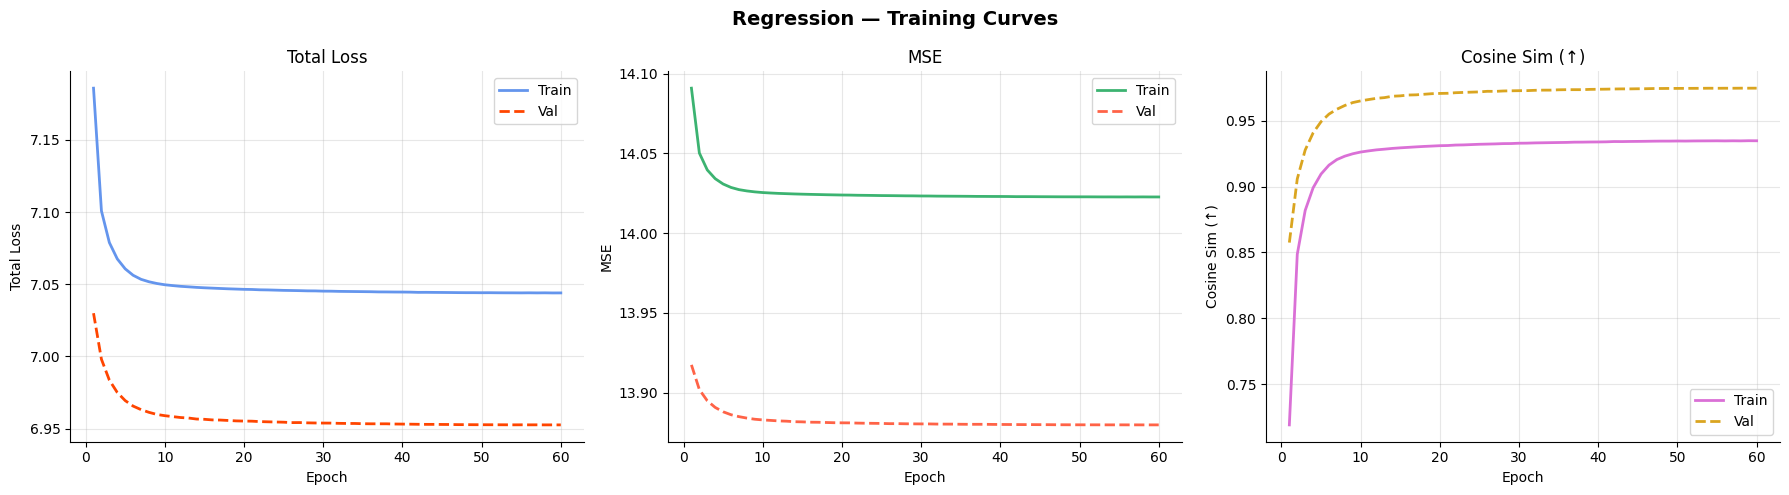

💾  Saved to outputs/regression_curves.png


In [16]:
# CELL 6.3 — Plot training curves

def plot_curves(history, title, save_dir):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{title} — Training Curves', fontsize=14, fontweight='bold')
    epochs = range(1, len(history['train_loss'])+1)
    specs = [
        ('Total Loss',     'train_loss','val_loss','cornflowerblue','orangered'),
        ('MSE',            'train_mse', 'val_mse', 'mediumseagreen','tomato'),
        ('Cosine Sim (↑)', 'train_cos', 'val_cos', 'orchid',        'goldenrod'),
    ]
    for ax, (ylabel, trk, vlk, tc, vc) in zip(axes, specs):
        ax.plot(epochs, history[trk], color=tc, lw=2, label='Train')
        ax.plot(epochs, history[vlk], color=vc, lw=2, ls='--', label='Val')
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel); ax.set_title(ylabel)
        ax.legend(); ax.grid(alpha=0.3)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout()
    path = Path(save_dir) / f'{title.lower().replace(" ","_")}_curves.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show(); print(f'💾  Saved to {path}')

plot_curves(reg_history, 'Regression', CFG.OUTPUT_DIR)


## Section 7 — Cross-Modal Distillation

In [17]:
# CELL 7.1 — Student model + distillation loss

class StudentMLP(nn.Module):
    """
    Student that learns to imitate the visual-only teacher using AV input.
    Input  : (B, 640) — concat[audio; visual]
    Output : embedding (B, 512),  logits (B, N_CLASSES)
    """
    def __init__(self, input_dim, teacher_dim, hidden_dims, dropout, n_classes):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.LayerNorm(h), nn.GELU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, teacher_dim))
        self.backbone   = nn.Sequential(*layers)
        self.classifier = nn.Linear(teacher_dim, n_classes)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        emb    = F.normalize(self.backbone(x), dim=-1)
        logits = self.classifier(emb)
        return emb, logits


class DistillLoss(nn.Module):
    """KL soft + CE hard + MSE embedding + CosSim alignment."""
    def __init__(self, T=4.0, alpha=0.7, beta=0.3):
        super().__init__()
        self.T=T; self.alpha=alpha; self.beta=beta
        self.ce=nn.CrossEntropyLoss(); self.mse=nn.MSELoss()

    def forward(self, s_emb, s_logits, t_emb, t_logits, labels):
        soft = F.kl_div(F.log_softmax(s_logits/self.T,-1),
                        F.softmax(t_logits/self.T,-1),
                        reduction='batchmean') * self.T**2
        hard = self.ce(s_logits, labels)
        emb  = self.mse(s_emb, t_emb)
        cos  = 1.0 - F.cosine_similarity(s_emb, t_emb, dim=-1).mean()
        total = self.alpha*soft + (1-self.alpha)*hard + self.beta*emb + self.beta*cos
        return total, {'soft_kl':soft.item(),'hard_ce':hard.item(),
                       'emb_mse':emb.item(),'cos_align':cos.item()}


student_model = StudentMLP(AV_DIM, GT_DIM, CFG.STUDENT_HIDDEN, CFG.DROPOUT,
                            CFG.N_CLASSES).to(DEVICE)
n_params_s = sum(p.numel() for p in student_model.parameters() if p.requires_grad)
print(f'✅  StudentMLP — params: {n_params_s:,}')


✅  StudentMLP — params: 613,673


In [18]:
# CELL 7.2 — Teacher linear probe (on visual-only embeddings)

class TeacherProbe(nn.Module):
    """Linear classifier on VGG16 visual embeddings → teacher logits."""
    def __init__(self, dim, n_classes):
        super().__init__()
        self.linear = nn.Linear(dim, n_classes)
    def forward(self, x): return self.linear(x)

def train_teacher_probe(train_data, val_data, dim, n_classes, epochs=25):
    class _DS(Dataset):
        def __init__(self, d):
            self.v = torch.from_numpy(d['visual_embs']).float()
            self.l = torch.from_numpy(d['label_ids']).long()
        def __len__(self): return len(self.l)
        def __getitem__(self, i): return self.v[i], self.l[i]

    probe = TeacherProbe(dim, n_classes).to(DEVICE)
    opt   = torch.optim.Adam(probe.parameters(), lr=1e-3)
    dl    = DataLoader(_DS(train_data), batch_size=256, shuffle=True)
    for _ in range(epochs):
        probe.train()
        for v, l in dl:
            v, l = v.to(DEVICE), l.to(DEVICE)
            loss = F.cross_entropy(probe(v), l)
            opt.zero_grad(); loss.backward(); opt.step()
    probe.eval()
    for p in probe.parameters(): p.requires_grad_(False)
    # Val accuracy
    vdl = DataLoader(_DS(val_data), batch_size=256)
    correct, total = 0, 0
    with torch.no_grad():
        for v, l in vdl:
            v, l = v.to(DEVICE), l.to(DEVICE)
            correct += (probe(v).argmax(-1)==l).sum().item(); total += len(l)
    print(f'   Teacher probe val acc: {100*correct/total:.1f}%')
    return probe

print('📐  Training teacher probe...')
teacher_probe = train_teacher_probe(train_data, val_data, GT_DIM, CFG.N_CLASSES)


📐  Training teacher probe...
   Teacher probe val acc: 51.7%


🎓  Training student (distillation)...
  Epoch   1/60 | train loss 10.0312  val loss 9.1967  val CosSim 0.4824
  Epoch  10/60 | train loss 5.8467  val loss 5.7437  val CosSim 0.4766
  Epoch  20/60 | train loss 5.2716  val loss 5.2420  val CosSim 0.5405
  Epoch  30/60 | train loss 5.0930  val loss 5.0940  val CosSim 0.5817
  Epoch  40/60 | train loss 5.0196  val loss 5.0373  val CosSim 0.6050
  Epoch  50/60 | train loss 4.9909  val loss 5.0151  val CosSim 0.6133
  Epoch  60/60 | train loss 4.9842  val loss 5.0095  val CosSim 0.6152

✅  Distillation done. Best val loss: 5.0095


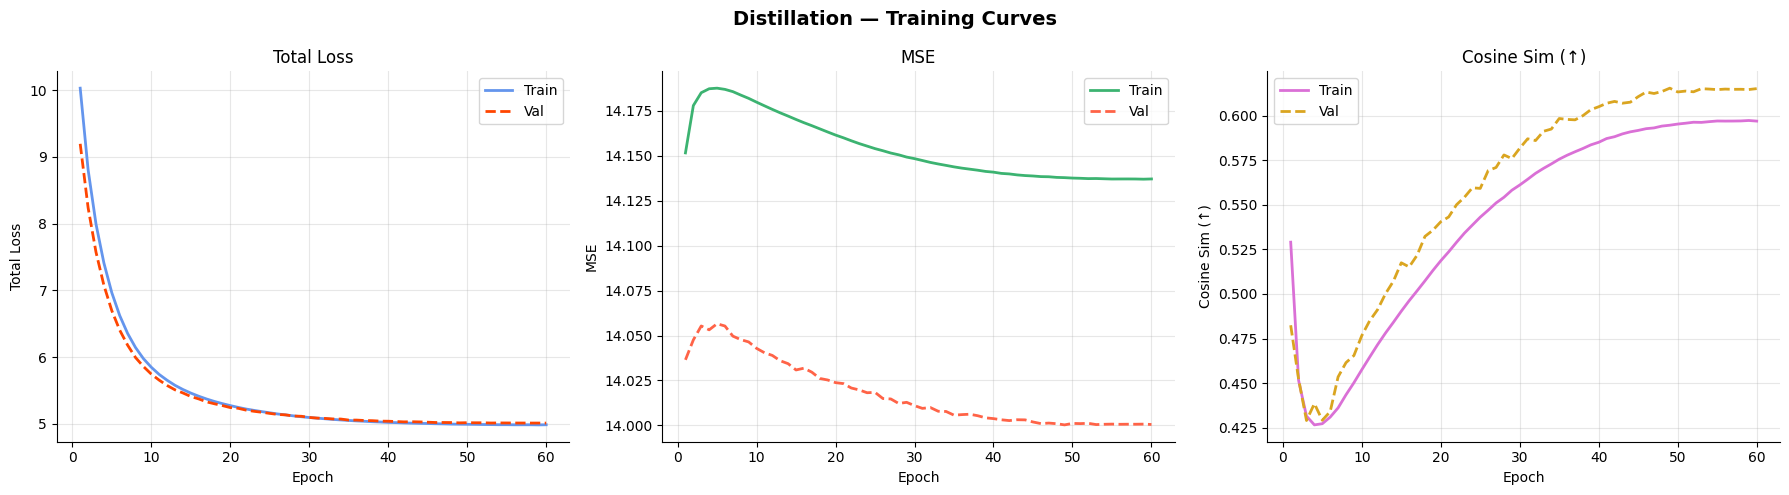

💾  Saved to outputs/distillation_curves.png


In [19]:
# CELL 7.3 — Distillation training loop

def train_distillation(student, teacher_probe, train_loader, val_loader, cfg: Config):
    criterion = DistillLoss(T=4.0, alpha=0.7, beta=0.3)
    opt       = torch.optim.AdamW(student.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    sched     = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.DIST_EPOCHS, eta_min=1e-6)
    scaler    = GradScaler('cuda', enabled=cfg.USE_AMP and DEVICE.type=='cuda')
    history   = {'train_loss':[],'val_loss':[],'train_mse':[],'val_mse':[],'train_cos':[],'val_cos':[]}
    best_val, best_state = float('inf'), None

    for epoch in range(1, cfg.DIST_EPOCHS + 1):
        student.train()
        tr = {k:0.0 for k in ['loss','mse','cos']}; n = 0
        for batch in train_loader:
            av  = batch['av_concat'].to(DEVICE)
            t_e = batch['visual_emb'].to(DEVICE)
            lbl = batch['label_id'].to(DEVICE)
            t_logits = teacher_probe(t_e)
            opt.zero_grad()
            with autocast('cuda', enabled=cfg.USE_AMP and DEVICE.type=='cuda'):
                s_e, s_logits = student(av)
                loss, sub = criterion(s_e, s_logits, t_e, t_logits, lbl)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
            scaler.step(opt); scaler.update()
            B = av.size(0)
            tr['loss']+=loss.item()*B; tr['mse']+=sub['emb_mse']*B
            tr['cos']+=(1-sub['cos_align'])*B; n+=B

        student.eval()
        vl = {k:0.0 for k in ['loss','mse','cos']}; nv = 0
        with torch.no_grad():
            for batch in val_loader:
                av  = batch['av_concat'].to(DEVICE)
                t_e = batch['visual_emb'].to(DEVICE)
                lbl = batch['label_id'].to(DEVICE)
                t_logits = teacher_probe(t_e)
                with autocast('cuda', enabled=cfg.USE_AMP and DEVICE.type=='cuda'):
                    s_e, s_logits = student(av)
                    loss, sub = criterion(s_e, s_logits, t_e, t_logits, lbl)
                B = av.size(0)
                vl['loss']+=loss.item()*B; vl['mse']+=sub['emb_mse']*B
                vl['cos']+=(1-sub['cos_align'])*B; nv+=B

        history['train_loss'].append(tr['loss']/n); history['val_loss'].append(vl['loss']/nv)
        history['train_mse'].append(tr['mse']/n);  history['val_mse'].append(vl['mse']/nv)
        history['train_cos'].append(tr['cos']/n);  history['val_cos'].append(vl['cos']/nv)
        sched.step()
        if vl['loss']/nv < best_val:
            best_val = vl['loss']/nv
            best_state = copy.deepcopy(student.state_dict())
        if epoch % 10 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{cfg.DIST_EPOCHS} | '
                  f'train loss {history["train_loss"][-1]:.4f}  '
                  f'val loss {history["val_loss"][-1]:.4f}  '
                  f'val CosSim {history["val_cos"][-1]:.4f}')

    student.load_state_dict(best_state)
    torch.save(student.state_dict(), Path(cfg.OUTPUT_DIR)/'distill_model.pt')
    print(f'\n✅  Distillation done. Best val loss: {best_val:.4f}')
    return history


print('🎓  Training student (distillation)...')
dist_history = train_distillation(student_model, teacher_probe, train_loader, val_loader, CFG)
plot_curves(dist_history, 'Distillation', CFG.OUTPUT_DIR)


## Section 8 — Evaluation (CosSim, MSE, Recall@K, MedR)

In [20]:
# CELL 8.1 — Evaluation helpers

def get_predictions(model, loader, is_student=False):
    model.eval()
    preds, targets, lbls = [], [], []
    with torch.no_grad():
        for batch in loader:
            av  = batch['av_concat'].to(DEVICE)
            tgt = batch['visual_emb'].to(DEVICE)
            lbl = batch['label_id']
            if is_student:
                emb, _ = model(av)
            else:
                emb = model(av)
            preds.append(emb.cpu().numpy())
            targets.append(tgt.cpu().numpy())
            lbls.append(lbl.numpy())
    return (np.concatenate(preds),
            np.concatenate(targets),
            np.concatenate(lbls))


def eval_cosine_mse(pred, target):
    pn = pred   / (np.linalg.norm(pred,   axis=1, keepdims=True) + 1e-8)
    tn = target / (np.linalg.norm(target, axis=1, keepdims=True) + 1e-8)
    cos = (pn * tn).sum(axis=1)
    mse = ((pred - target)**2).mean(axis=1)
    return {'mean_cos': float(cos.mean()), 'std_cos': float(cos.std()),
            'mean_mse': float(mse.mean()), 'std_mse': float(mse.std()),
            'per_cos': cos, 'per_mse': mse}


def eval_retrieval(q_embs, g_embs, q_labels, g_labels, ks=(1,5,10)):
    q = q_embs / (np.linalg.norm(q_embs, axis=1, keepdims=True) + 1e-8)
    g = g_embs / (np.linalg.norm(g_embs, axis=1, keepdims=True) + 1e-8)
    sim = q @ g.T   # (Nq, Ng)
    ranks = []
    for i in range(len(q)):
        order = np.argsort(-sim[i])
        match = g_labels[order] == q_labels[i]
        ranks.append(int(np.argmax(match)) + 1 if match.any() else len(g)+1)
    ranks = np.array(ranks)
    res = {f'R@{k}': float((ranks<=k).mean()*100) for k in ks}
    res['MedR'] = float(np.median(ranks))
    res['ranks'] = ranks
    return res


print('✅  Evaluation functions defined.')


✅  Evaluation functions defined.


In [22]:
# CELL 8.2 — Run evaluation on test split

print('🔍  Evaluating on TEST split...')

reg_pred,  reg_gt,  reg_lbl  = get_predictions(reg_model,     test_loader, is_student=False)
dist_pred, dist_gt, dist_lbl = get_predictions(student_model, test_loader, is_student=True)

reg_cm  = eval_cosine_mse(reg_pred,  reg_gt)
dist_cm = eval_cosine_mse(dist_pred, dist_gt)

reg_ret  = eval_retrieval(reg_pred,  reg_gt,  reg_lbl,  reg_lbl)
dist_ret = eval_retrieval(dist_pred, dist_gt, dist_lbl, dist_lbl)

print('\n' + '='*58)
print('  TEST RESULTS')
print('='*58)
for name, cm, ret in [('Regression',   reg_cm,  reg_ret),
                       ('Distillation', dist_cm, dist_ret)]:
    print(f'\n  {name}:')
    print(f'    CosSim  : {cm["mean_cos"]:.4f} ± {cm["std_cos"]:.4f}')
    print(f'    MSE     : {cm["mean_mse"]:.4f} ± {cm["std_mse"]:.4f}')
    print(f'    R@1/5/10: {ret["R@1"]:.1f}% / {ret["R@5"]:.1f}% / {ret["R@10"]:.1f}%')
    print(f'    MedR    : {ret["MedR"]:.1f}')
print('='*58)


🔍  Evaluating on TEST split...

  TEST RESULTS

  Regression:
    CosSim  : 0.9744 ± 0.0097
    MSE     : 13.8927 ± 10.5980
    R@1/5/10: 99.8% / 100.0% / 100.0%
    MedR    : 1.0

  Distillation:
    CosSim  : 0.6136 ± 0.1119
    MSE     : 14.0135 ± 10.6677
    R@1/5/10: 46.7% / 74.6% / 84.5%
    MedR    : 2.0


## Section 9 — Results Dashboard

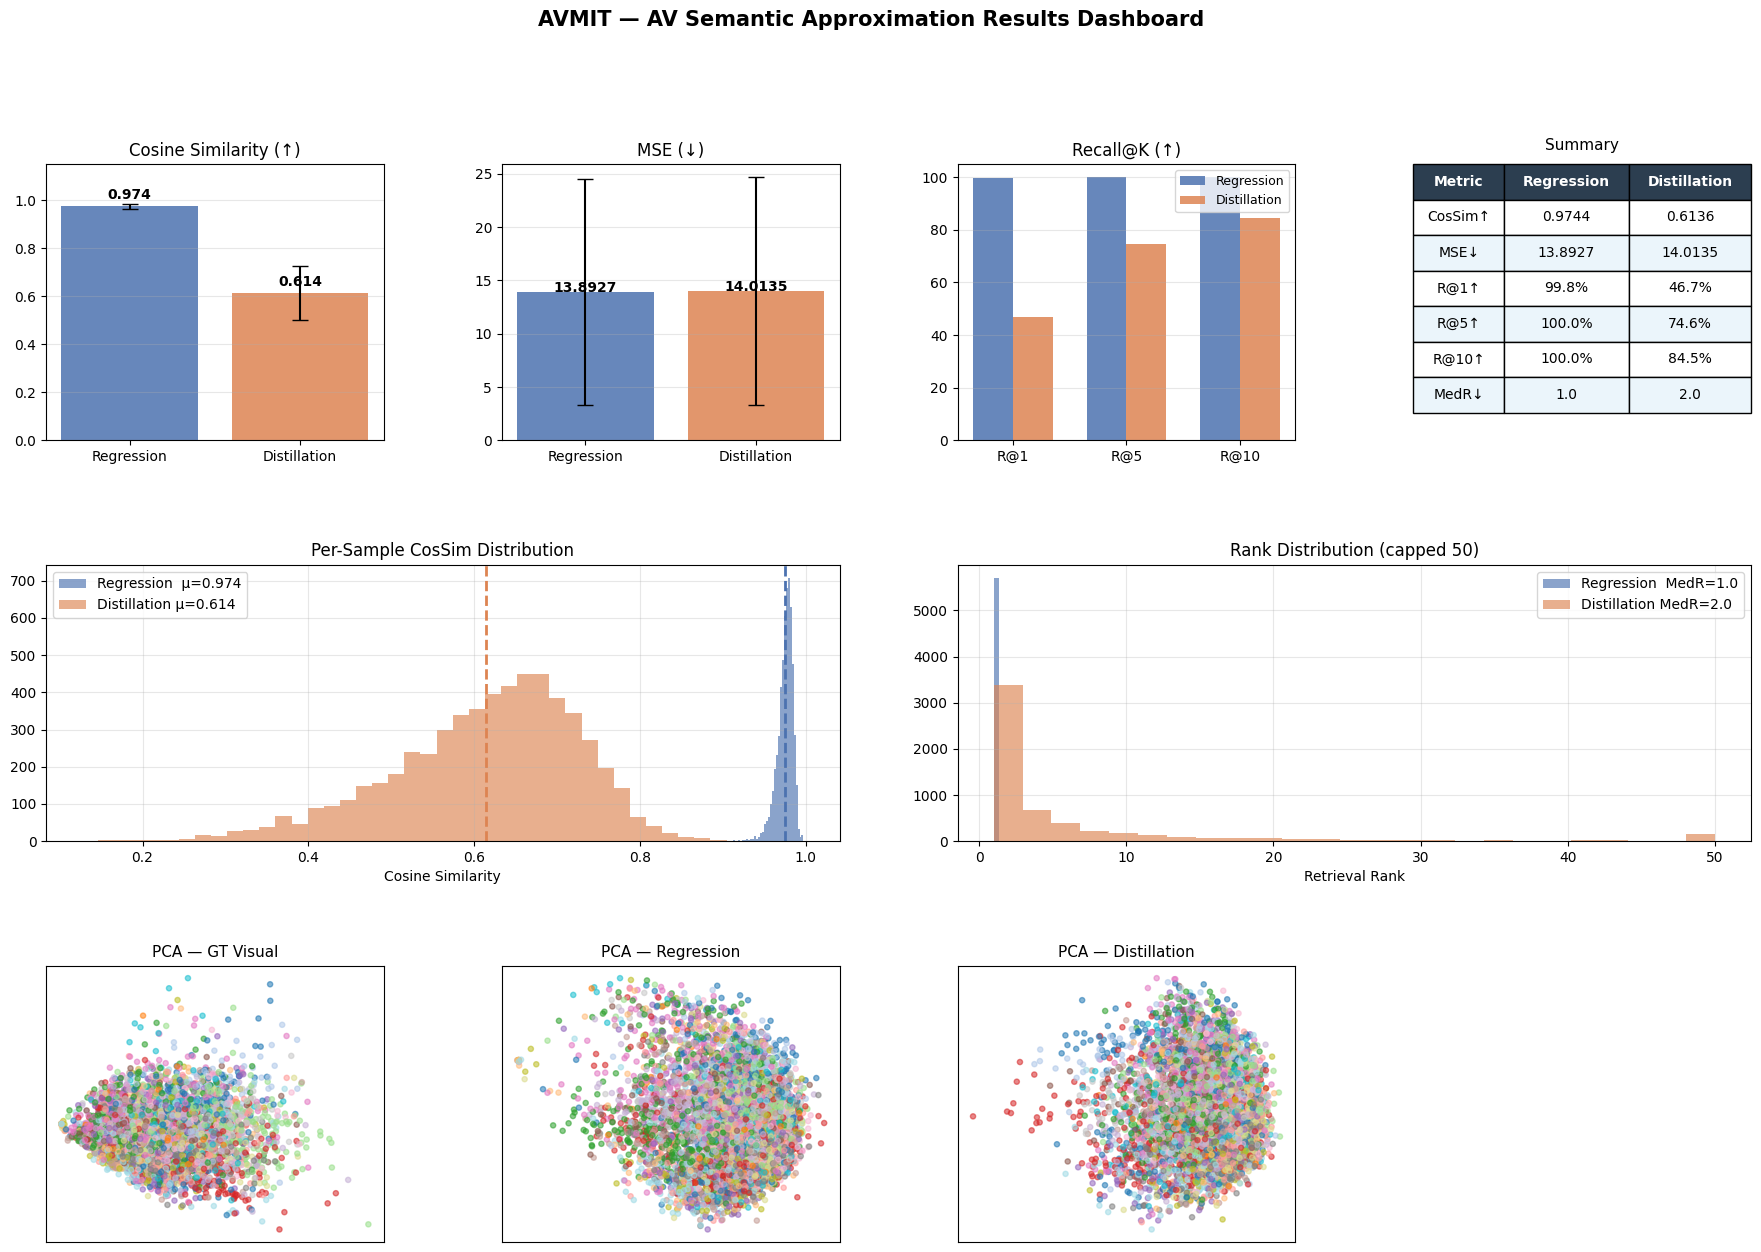

💾  Saved to outputs/results_dashboard.png


In [23]:
# CELL 9.1 — Comparative results dashboard (Matplotlib)

def results_dashboard(reg_cm, reg_ret, dist_cm, dist_ret,
                      reg_pred, dist_pred, gt_embs, labels, save_dir):
    fig = plt.figure(figsize=(22, 14))
    fig.suptitle('AVMIT — AV Semantic Approximation Results Dashboard',
                 fontsize=15, fontweight='bold', y=0.99)
    gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)
    C  = ['#4C72B0', '#DD8452']
    M  = ['Regression', 'Distillation']

    # CosSim bar
    ax = fig.add_subplot(gs[0,0])
    vals = [reg_cm['mean_cos'], dist_cm['mean_cos']]
    errs = [reg_cm['std_cos'],  dist_cm['std_cos']]
    bars = ax.bar(M, vals, color=C, yerr=errs, capsize=6, alpha=0.85)
    ax.set_ylim(0,1.15); ax.set_title('Cosine Similarity (↑)'); ax.grid(axis='y',alpha=0.3)
    for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2, v+0.03, f'{v:.3f}', ha='center', fontweight='bold')

    # MSE bar
    ax = fig.add_subplot(gs[0,1])
    vals = [reg_cm['mean_mse'], dist_cm['mean_mse']]
    errs = [reg_cm['std_mse'],  dist_cm['std_mse']]
    bars = ax.bar(M, vals, color=C, yerr=errs, capsize=6, alpha=0.85)
    ax.set_title('MSE (↓)'); ax.grid(axis='y',alpha=0.3)
    for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2, v+0.001, f'{v:.4f}', ha='center', fontweight='bold')

    # Recall@K
    ax = fig.add_subplot(gs[0,2])
    ks = ['R@1','R@5','R@10']
    x  = np.arange(len(ks)); w = 0.35
    ax.bar(x-w/2, [reg_ret[k]  for k in ks], w, label='Regression',   color=C[0], alpha=0.85)
    ax.bar(x+w/2, [dist_ret[k] for k in ks], w, label='Distillation', color=C[1], alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(ks); ax.set_title('Recall@K (↑)')
    ax.legend(fontsize=9); ax.grid(axis='y',alpha=0.3)

    # Summary table
    ax = fig.add_subplot(gs[0,3]); ax.axis('off')
    rows = [['Metric','Regression','Distillation'],
            ['CosSim↑', f'{reg_cm["mean_cos"]:.4f}', f'{dist_cm["mean_cos"]:.4f}'],
            ['MSE↓',    f'{reg_cm["mean_mse"]:.4f}', f'{dist_cm["mean_mse"]:.4f}'],
            ['R@1↑',    f'{reg_ret["R@1"]:.1f}%',    f'{dist_ret["R@1"]:.1f}%'],
            ['R@5↑',    f'{reg_ret["R@5"]:.1f}%',    f'{dist_ret["R@5"]:.1f}%'],
            ['R@10↑',   f'{reg_ret["R@10"]:.1f}%',   f'{dist_ret["R@10"]:.1f}%'],
            ['MedR↓',   f'{reg_ret["MedR"]:.1f}',    f'{dist_ret["MedR"]:.1f}']]
    t = ax.table(cellText=rows[1:], colLabels=rows[0], cellLoc='center', loc='center',
                 bbox=[0,0.1,1,0.9])
    t.auto_set_font_size(False); t.set_fontsize(10); t.auto_set_column_width([0,1,2])
    for (r,c),cell in t.get_celld().items():
        if r==0: cell.set_facecolor('#2C3E50'); cell.set_text_props(color='white',fontweight='bold')
        elif r%2==0: cell.set_facecolor('#EBF5FB')
    ax.set_title('Summary', fontsize=11, pad=10)

    # CosSim distribution
    ax = fig.add_subplot(gs[1,:2])
    ax.hist(reg_cm['per_cos'],  bins=40, alpha=0.65, color=C[0], label=f'Regression  μ={reg_cm["mean_cos"]:.3f}')
    ax.hist(dist_cm['per_cos'], bins=40, alpha=0.65, color=C[1], label=f'Distillation μ={dist_cm["mean_cos"]:.3f}')
    for v,c in zip([reg_cm['mean_cos'],dist_cm['mean_cos']],C): ax.axvline(v,color=c,ls='--',lw=2)
    ax.set_xlabel('Cosine Similarity'); ax.set_title('Per-Sample CosSim Distribution')
    ax.legend(); ax.grid(alpha=0.3)

    # Rank histogram
    ax = fig.add_subplot(gs[1,2:])
    cap = min(50, len(labels))
    ax.hist(np.minimum(reg_ret['ranks'],  cap), bins=25, alpha=0.65, color=C[0], label=f'Regression  MedR={reg_ret["MedR"]:.1f}')
    ax.hist(np.minimum(dist_ret['ranks'], cap), bins=25, alpha=0.65, color=C[1], label=f'Distillation MedR={dist_ret["MedR"]:.1f}')
    ax.set_xlabel('Retrieval Rank'); ax.set_title('Rank Distribution (capped 50)')
    ax.legend(); ax.grid(alpha=0.3)

    # PCA scatter: GT vs Reg vs Dist
    pca2 = PCA(n_components=2, random_state=SEED)
    all2d = pca2.fit_transform(np.vstack([gt_embs, reg_pred, dist_pred]))
    N = len(gt_embs)
    for ci, (name, arr) in enumerate([('GT Visual',gt_embs[:N]),('Regression',reg_pred),('Distillation',dist_pred)]):
        ax = fig.add_subplot(gs[2,ci])
        d2 = all2d[ci*N:(ci+1)*N]
        ax.scatter(d2[:,0], d2[:,1], c=labels[:len(d2)], cmap='tab20', alpha=0.55, s=14)
        ax.set_title(f'PCA — {name}', fontsize=11); ax.set_xticks([]); ax.set_yticks([])

    path = Path(save_dir)/'results_dashboard.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show(); print(f'💾  Saved to {path}')


results_dashboard(reg_cm, reg_ret, dist_cm, dist_ret,
                  reg_pred, dist_pred, reg_gt, reg_lbl, CFG.OUTPUT_DIR)


## Section 10 — Save Artifacts

In [24]:
# CELL 10.1 — Save models, histories, metrics, config

import dataclasses

out = Path(CFG.OUTPUT_DIR)

# Models
torch.save(reg_model.state_dict(),     out/'reg_model_final.pt')
torch.save(student_model.state_dict(), out/'distill_model_final.pt')
torch.save(teacher_probe.state_dict(), out/'teacher_probe_final.pt')

# Histories
for name, hist in [('reg_history', reg_history), ('dist_history', dist_history)]:
    with open(out/f'{name}.json','w') as f:
        json.dump({k: (v.tolist() if isinstance(v,np.ndarray) else v)
                   for k,v in hist.items()}, f, indent=2)

# Metrics
results = {
    'regression'  : {'cosine': {'mean':reg_cm['mean_cos'],'std':reg_cm['std_cos']},
                     'mse'   : {'mean':reg_cm['mean_mse'],'std':reg_cm['std_mse']},
                     'retrieval': {k:v for k,v in reg_ret.items() if k!='ranks'}},
    'distillation': {'cosine': {'mean':dist_cm['mean_cos'],'std':dist_cm['std_cos']},
                     'mse'   : {'mean':dist_cm['mean_mse'],'std':dist_cm['std_mse']},
                     'retrieval': {k:v for k,v in dist_ret.items() if k!='ranks'}},
}
with open(out/'final_results.json','w') as f:
    json.dump(results, f, indent=2)

# Config
with open(out/'config.json','w') as f:
    json.dump(CFG.__dict__, f, indent=2, default=str)

print('='*50)
print('✅  ALL ARTIFACTS SAVED')
print('='*50)
for p in sorted(out.iterdir()):
    if p.is_file():
        print(f'   {p.name:<40s}  {p.stat().st_size/1024:6.1f} KB')


✅  ALL ARTIFACTS SAVED
   config.json                                  0.6 KB
   dist_history.json                            8.4 KB
   distill_model.pt                          2402.1 KB
   distill_model_final.pt                    2402.2 KB
   distillation_curves.png                    133.7 KB
   embedding_vis.png                         1357.7 KB
   final_results.json                           0.7 KB
   reg_history.json                             8.4 KB
   reg_model.pt                              3346.2 KB
   reg_model_final.pt                        3346.3 KB
   regression_curves.png                       97.5 KB
   results_dashboard.png                      795.4 KB
   teacher_probe_final.pt                      84.1 KB
   umap_3d.html                              5684.2 KB


---
## Pipeline Summary

| Stage | Input | Output |
|---|---|---|
| **TFRecord Parse** | gzip SequenceExample per clip | `audio (T,128)`, `visual (T,512)`, `label` |
| **Mean-Pool** | Temporal embeddings | Flat `(128,)` audio, `(512,)` visual per sample |
| **Dim Reduction** | Concat AV `(640,)` | PCA / t-SNE / UMAP 2D/3D plots |
| **Fusion MLP (Reg)** | AV concat `(640,)` | Predicted visual GT `(512,)` |
| **Distillation** | AV concat `(640,)` | Student matches teacher visual emb |
| **Evaluation** | Predictions vs GT visual | CosSim, MSE, R@K, MedR |

### To run on your full AVMIT tar:
1. Set `CFG.TAR_PATH` in Cell 2.1 to your `.tar` file path
2. Run all cells — embeddings are parsed once and cached in `./avmit_cache/`
3. Re-runs load from cache instantly
